<a href="https://colab.research.google.com/github/Dawood-Ali123/Pytorch_learning/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [138]:
!pip install nltk

In [139]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
from torch.utils.data import Dataset,DataLoader
from nltk.tokenize import word_tokenize
import nltk

In [140]:
document="""Artificial intelligence is transforming the world.
Machine learning is a subset of artificial intelligence.
Deep learning is a subset of machine learning.
Neural networks are inspired by the human brain.
Artificial intelligence helps solve complex problems.
Deep learning models require large amounts of data.
Data science combines statistics and programming.
Python is one of the most popular programming languages.
PyTorch is widely used for deep learning projects.
TensorFlow is another popular deep learning framework.
Recurrent neural networks are used for sequence data.
LSTM networks solve the long term dependency problem.
GRU is a simplified version of LSTM.
Transformers are more powerful than recurrent networks.
Attention mechanisms help models focus on important information.
Large language models are based on transformer architectures.
ChatGPT is an example of a large language model.
Natural language processing deals with text data.
Computer vision deals with image data.
Convolutional neural networks are used for image classification.
Transfer learning helps when training data is limited.
Feature extraction is a common transfer learning technique.
Fine tuning improves the performance of pretrained models.
Optimization algorithms help neural networks learn efficiently.
Adam is a popular optimizer for deep learning.
Loss functions measure prediction errors.
Backpropagation updates the weights of a neural network.
Gradient descent minimizes the loss function.
Batch normalization improves training stability.
Dropout helps reduce overfitting.
Regularization techniques improve model generalization.
Embeddings convert words into dense numerical vectors.
Tokenization converts text into smaller units called tokens.
Vector databases are used in retrieval augmented generation.
Retrieval augmented generation combines search and generation.
Generative AI can create text images and code.
Language models predict the next word in a sequence.
Sequence models process information step by step.
Artificial intelligence is changing many industries.
Deep learning has revolutionized computer vision.
Machine learning enables computers to learn from data.
Data is the fuel of artificial intelligence.
Learning never stops in the field of technology."""

In [141]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [142]:
#tokenize
tokens=word_tokenize(document.lower())

In [143]:
vocab={'<unk>':0}
Counter(tokens).keys()

dict_keys(['artificial', 'intelligence', 'is', 'transforming', 'the', 'world', '.', 'machine', 'learning', 'a', 'subset', 'of', 'deep', 'neural', 'networks', 'are', 'inspired', 'by', 'human', 'brain', 'helps', 'solve', 'complex', 'problems', 'models', 'require', 'large', 'amounts', 'data', 'science', 'combines', 'statistics', 'and', 'programming', 'python', 'one', 'most', 'popular', 'languages', 'pytorch', 'widely', 'used', 'for', 'projects', 'tensorflow', 'another', 'framework', 'recurrent', 'sequence', 'lstm', 'long', 'term', 'dependency', 'problem', 'gru', 'simplified', 'version', 'transformers', 'more', 'powerful', 'than', 'attention', 'mechanisms', 'help', 'focus', 'on', 'important', 'information', 'language', 'based', 'transformer', 'architectures', 'chatgpt', 'an', 'example', 'model', 'natural', 'processing', 'deals', 'with', 'text', 'computer', 'vision', 'image', 'convolutional', 'classification', 'transfer', 'when', 'training', 'limited', 'feature', 'extraction', 'common', 'te

In [144]:
for token in Counter(tokens).keys():
  if token not in vocab:
    vocab[token]=len(vocab)

In [145]:
len(vocab)

174

In [146]:
#extract the sentences from the data
input_sentence=document.split('\n')

In [147]:
def text_to_index(sentence,vocab):
  numerical_sentence=[]
  for token in sentence:
    if token in vocab:
      numerical_sentence.append(vocab[token])
    else:
      numerical_sentence.append(vocab['<unk>'])
  return numerical_sentence

In [148]:
# we have to tokenize the sentence
input_numerical_sentence=[]
for sentence in input_sentence:
  input_numerical_sentence.append(text_to_index(word_tokenize(sentence.lower()),vocab))

In [149]:
input_numerical_sentence

[[1, 2, 3, 4, 5, 6, 7],
 [8, 9, 3, 10, 11, 12, 1, 2, 7],
 [13, 9, 3, 10, 11, 12, 8, 9, 7],
 [14, 15, 16, 17, 18, 5, 19, 20, 7],
 [1, 2, 21, 22, 23, 24, 7],
 [13, 9, 25, 26, 27, 28, 12, 29, 7],
 [29, 30, 31, 32, 33, 34, 7],
 [35, 3, 36, 12, 5, 37, 38, 34, 39, 7],
 [40, 3, 41, 42, 43, 13, 9, 44, 7],
 [45, 3, 46, 38, 13, 9, 47, 7],
 [48, 14, 15, 16, 42, 43, 49, 29, 7],
 [50, 15, 22, 5, 51, 52, 53, 54, 7],
 [55, 3, 10, 56, 57, 12, 50, 7],
 [58, 16, 59, 60, 61, 48, 15, 7],
 [62, 63, 64, 25, 65, 66, 67, 68, 7],
 [27, 69, 25, 16, 70, 66, 71, 72, 7],
 [73, 3, 74, 75, 12, 10, 27, 69, 76, 7],
 [77, 69, 78, 79, 80, 81, 29, 7],
 [82, 83, 79, 80, 84, 29, 7],
 [85, 14, 15, 16, 42, 43, 84, 86, 7],
 [87, 9, 21, 88, 89, 29, 3, 90, 7],
 [91, 92, 3, 10, 93, 87, 9, 94, 7],
 [95, 96, 97, 5, 98, 12, 99, 25, 7],
 [100, 101, 64, 14, 15, 102, 103, 7],
 [104, 3, 10, 38, 105, 43, 13, 9, 7],
 [106, 107, 108, 109, 110, 7],
 [111, 112, 5, 113, 12, 10, 14, 114, 7],
 [115, 116, 117, 5, 106, 118, 7],
 [119, 120, 97, 8

In [150]:
len(input_numerical_sentence)

43

In [151]:
training_sequence=[]
for sentence in input_numerical_sentence:
  for i in range(1,len(sentence)):
    training_sequence.append(sentence[:i+1])

In [152]:
training_sequence

[[1, 2],
 [1, 2, 3],
 [1, 2, 3, 4],
 [1, 2, 3, 4, 5],
 [1, 2, 3, 4, 5, 6],
 [1, 2, 3, 4, 5, 6, 7],
 [8, 9],
 [8, 9, 3],
 [8, 9, 3, 10],
 [8, 9, 3, 10, 11],
 [8, 9, 3, 10, 11, 12],
 [8, 9, 3, 10, 11, 12, 1],
 [8, 9, 3, 10, 11, 12, 1, 2],
 [8, 9, 3, 10, 11, 12, 1, 2, 7],
 [13, 9],
 [13, 9, 3],
 [13, 9, 3, 10],
 [13, 9, 3, 10, 11],
 [13, 9, 3, 10, 11, 12],
 [13, 9, 3, 10, 11, 12, 8],
 [13, 9, 3, 10, 11, 12, 8, 9],
 [13, 9, 3, 10, 11, 12, 8, 9, 7],
 [14, 15],
 [14, 15, 16],
 [14, 15, 16, 17],
 [14, 15, 16, 17, 18],
 [14, 15, 16, 17, 18, 5],
 [14, 15, 16, 17, 18, 5, 19],
 [14, 15, 16, 17, 18, 5, 19, 20],
 [14, 15, 16, 17, 18, 5, 19, 20, 7],
 [1, 2],
 [1, 2, 21],
 [1, 2, 21, 22],
 [1, 2, 21, 22, 23],
 [1, 2, 21, 22, 23, 24],
 [1, 2, 21, 22, 23, 24, 7],
 [13, 9],
 [13, 9, 25],
 [13, 9, 25, 26],
 [13, 9, 25, 26, 27],
 [13, 9, 25, 26, 27, 28],
 [13, 9, 25, 26, 27, 28, 12],
 [13, 9, 25, 26, 27, 28, 12, 29],
 [13, 9, 25, 26, 27, 28, 12, 29, 7],
 [29, 30],
 [29, 30, 31],
 [29, 30, 31, 32],
 [29, 3

In [153]:
#now we have to use the padding concept
max_length=max([len(sentence) for sentence in training_sequence])

In [154]:
max_length

10

In [155]:
padded_training_sequence=[]
for sequence_original in training_sequence:
  # Create a copy to pad, so the original training_sequence is not modified
  sequence_copy = list(sequence_original)
  sequence_copy.extend([0]*(max_length-len(sequence_copy)))
  padded_training_sequence.append(sequence_copy)


In [156]:
padded_training_sequence

[[1, 2, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, 2, 3, 0, 0, 0, 0, 0, 0, 0],
 [1, 2, 3, 4, 0, 0, 0, 0, 0, 0],
 [1, 2, 3, 4, 5, 0, 0, 0, 0, 0],
 [1, 2, 3, 4, 5, 6, 0, 0, 0, 0],
 [1, 2, 3, 4, 5, 6, 7, 0, 0, 0],
 [8, 9, 0, 0, 0, 0, 0, 0, 0, 0],
 [8, 9, 3, 0, 0, 0, 0, 0, 0, 0],
 [8, 9, 3, 10, 0, 0, 0, 0, 0, 0],
 [8, 9, 3, 10, 11, 0, 0, 0, 0, 0],
 [8, 9, 3, 10, 11, 12, 0, 0, 0, 0],
 [8, 9, 3, 10, 11, 12, 1, 0, 0, 0],
 [8, 9, 3, 10, 11, 12, 1, 2, 0, 0],
 [8, 9, 3, 10, 11, 12, 1, 2, 7, 0],
 [13, 9, 0, 0, 0, 0, 0, 0, 0, 0],
 [13, 9, 3, 0, 0, 0, 0, 0, 0, 0],
 [13, 9, 3, 10, 0, 0, 0, 0, 0, 0],
 [13, 9, 3, 10, 11, 0, 0, 0, 0, 0],
 [13, 9, 3, 10, 11, 12, 0, 0, 0, 0],
 [13, 9, 3, 10, 11, 12, 8, 0, 0, 0],
 [13, 9, 3, 10, 11, 12, 8, 9, 0, 0],
 [13, 9, 3, 10, 11, 12, 8, 9, 7, 0],
 [14, 15, 0, 0, 0, 0, 0, 0, 0, 0],
 [14, 15, 16, 0, 0, 0, 0, 0, 0, 0],
 [14, 15, 16, 17, 0, 0, 0, 0, 0, 0],
 [14, 15, 16, 17, 18, 0, 0, 0, 0, 0],
 [14, 15, 16, 17, 18, 5, 0, 0, 0, 0],
 [14, 15, 16, 17, 18, 5, 19, 0, 0, 0],
 [14, 15, 16,

In [157]:
padded_training_sequence=torch.tensor(padded_training_sequence,dtype=torch.long)

In [158]:
padded_training_sequence.shape

torch.Size([311, 10])

In [159]:
X_list = []
Y_list = []

for seq in training_sequence:
    X_list.append(seq[:-1]) # Input is all tokens except the last one
    Y_list.append(seq[-1])  # Target is the last token

# Calculate max_input_length for padding X (which is max_length of the actual input sequences)
# This is max_length from before minus 1, as Y takes one token.
max_input_length = max_length - 1

# Pad X_list
padded_X = []
for seq_x in X_list:
    padded_x = [0] * (max_input_length - len(seq_x)) + seq_x
    padded_X.append(padded_x)

X = torch.tensor(padded_X, dtype=torch.long)
Y = torch.tensor(Y_list, dtype=torch.long)

### Fixing X and Y generation

The `training_sequence` was previously padded in-place, causing incorrect `Y` targets. We need to re-initialize `training_sequence` from `input_numerical_sentence` to ensure it's in its unpadded form before splitting into `X` and `Y`.

In [160]:
# Re-initialize training_sequence to its unpadded state
training_sequence = []
for sentence in input_numerical_sentence:
    for i in range(1, len(sentence)):
        training_sequence.append(sentence[:i+1])

print(f"Re-initialized training_sequence with {len(training_sequence)} sequences.")

Re-initialized training_sequence with 311 sequences.


In [161]:
X

tensor([[  0,   0,   0,  ...,   0,   0,   1],
        [  0,   0,   0,  ...,   0,   1,   2],
        [  0,   0,   0,  ...,   1,   2,   3],
        ...,
        [  0,   0,   0,  ..., 144,   5, 172],
        [  0,   0,   9,  ...,   5, 172,  12],
        [  0,   9, 170,  ..., 172,  12, 173]])

In [162]:
Y

tensor([  2,   3,   4,   5,   6,   7,   9,   3,  10,  11,  12,   1,   2,   7,
          9,   3,  10,  11,  12,   8,   9,   7,  15,  16,  17,  18,   5,  19,
         20,   7,   2,  21,  22,  23,  24,   7,   9,  25,  26,  27,  28,  12,
         29,   7,  30,  31,  32,  33,  34,   7,   3,  36,  12,   5,  37,  38,
         34,  39,   7,   3,  41,  42,  43,  13,   9,  44,   7,   3,  46,  38,
         13,   9,  47,   7,  14,  15,  16,  42,  43,  49,  29,   7,  15,  22,
          5,  51,  52,  53,  54,   7,   3,  10,  56,  57,  12,  50,   7,  16,
         59,  60,  61,  48,  15,   7,  63,  64,  25,  65,  66,  67,  68,   7,
         69,  25,  16,  70,  66,  71,  72,   7,   3,  74,  75,  12,  10,  27,
         69,  76,   7,  69,  78,  79,  80,  81,  29,   7,  83,  79,  80,  84,
         29,   7,  14,  15,  16,  42,  43,  84,  86,   7,   9,  21,  88,  89,
         29,   3,  90,   7,  92,   3,  10,  93,  87,   9,  94,   7,  96,  97,
          5,  98,  12,  99,  25,   7, 101,  64,  14,  15, 102, 1

In [163]:
class CustomDataset(Dataset):
  def __init__(self,X,Y):
    self.X=X
    self.Y=Y
  def __len__(self):
    return self.X.shape[0]
  def __getitem__(self,index):
    return self.X[index],self.Y[index]

In [164]:
dataset=CustomDataset(X,Y)
len(dataset)

311

In [165]:
dataloader=DataLoader(dataset,batch_size=32,shuffle=True)


In [166]:
for input,output in dataloader:
  print(input,output)

tensor([[  0,   0,   0,   0,   0,   0,   0,  77,  69],
        [  0,   0,   0,   0,   0,   0,   0,   0,  35],
        [  0,   0,   0,  35,   3,  36,  12,   5,  37],
        [  0,   0,   0,   0,  85,  14,  15,  16,  42],
        [  0,   0,   0,   0,   0,   0,   0, 115, 116],
        [  0,   0,   0,   0,   0,   0,   0,   0, 111],
        [  0,   0,  85,  14,  15,  16,  42,  43,  84],
        [  0,   0,   0,   0,   0,   0,   0,   0,  95],
        [  0,   0,   0,   0,   8,   9,   3,  10,  11],
        [  0,   0,   0,   0,  29,   3,   5, 169,  12],
        [  0,   0,  50,  15,  22,   5,  51,  52,  53],
        [  0,   0,   0,   0,   0,   0,   0,   0, 104],
        [  0,   0,   0,   0,  48,  14,  15,  16,  42],
        [  0,   0,   0,   0,   0,   0,   0,   0,  85],
        [  0,   0,   0,   0,   0,   0,   0,   0,   8],
        [  0,   0,   0,   0,   0,  29,   3,   5, 169],
        [  0,   0,   0,   0,   0,   0,   0,   0,  40],
        [  0,   0,   0,   0,   1,   2,   3, 160, 161],
        [ 

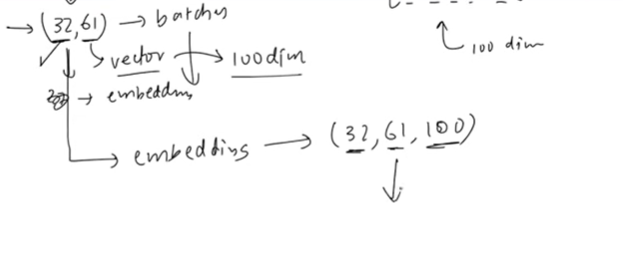

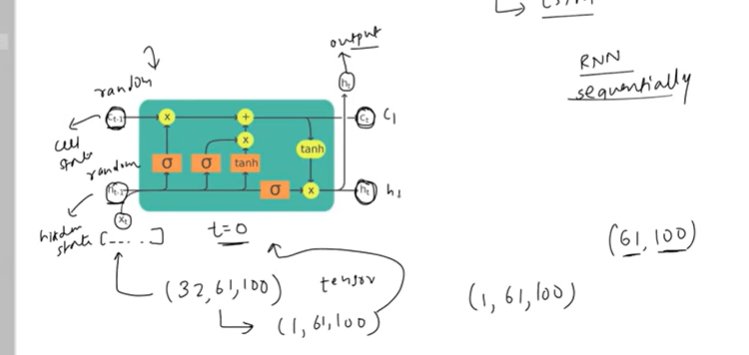

In [167]:
class LSTmodel(nn.Module):
  def __init__(self,vocab_size):
    super().__init__()
    self.embedding=nn.Embedding(vocab_size,100)
    self.lstm=nn.LSTM(100,150,batch_first=True)
    self.fc=nn.Linear(150,vocab_size)
  def forward(self,x):
    embedded=self.embedding(x)
    intermediate_hidden_state,(final_hidden_state,final_cell_state)=self.lstm(embedded)
    output=self.fc(final_hidden_state.squeeze(0))
    return output

In [168]:
model=LSTmodel(len(vocab))
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

LSTmodel(
  (embedding): Embedding(174, 100)
  (lstm): LSTM(100, 150, batch_first=True)
  (fc): Linear(in_features=150, out_features=174, bias=True)
)

In [169]:
epoches=50
learning_rate=0.001
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)

In [170]:
for epoch in range(epoches):
  total_loss=0
  for batch_X,batch_Y in dataloader:
    batch_X,batch_Y=batch_X.to(device),batch_Y.to(device)
    optimizer.zero_grad()
    output=model(batch_X)
    loss=criterion(output,batch_Y)
    loss.backward()
    optimizer.step()
    total_loss=total_loss+loss.item()
    avg_loss=total_loss/len(dataloader)
  print('epoch:{},loss:{}'.format(epoch,avg_loss))

epoch:0,loss:5.150935697555542
epoch:1,loss:4.908872795104981
epoch:2,loss:4.562727975845337
epoch:3,loss:4.210008645057679
epoch:4,loss:3.8795329332351685
epoch:5,loss:3.610228943824768
epoch:6,loss:3.3650614500045775
epoch:7,loss:3.116475534439087
epoch:8,loss:2.8911526441574096
epoch:9,loss:2.6478646278381346
epoch:10,loss:2.4156286478042603
epoch:11,loss:2.189038062095642
epoch:12,loss:1.9983180522918702
epoch:13,loss:1.792360544204712
epoch:14,loss:1.627737247943878
epoch:15,loss:1.450118601322174
epoch:16,loss:1.3045730590820312
epoch:17,loss:1.1775320410728454
epoch:18,loss:1.0646425366401673
epoch:19,loss:0.9372952461242676
epoch:20,loss:0.8342551469802857
epoch:21,loss:0.7483893513679505
epoch:22,loss:0.6768413603305816
epoch:23,loss:0.6148363828659058
epoch:24,loss:0.552004137635231
epoch:25,loss:0.5036478340625763
epoch:26,loss:0.4604224503040314
epoch:27,loss:0.4221292495727539
epoch:28,loss:0.38717286586761473
epoch:29,loss:0.3575545221567154
epoch:30,loss:0.32710893005132

In [171]:
def prediction(model,vocab,text):
  tokenized_text=word_tokenize(text.lower())
  numerical_text=text_to_index(tokenized_text,vocab)
  # Pad the numerical_text and convert to tensor
  padded_list = [0]*(max_length-len(numerical_text)) + numerical_text
  padded_text = torch.tensor(padded_list, dtype=torch.long).unsqueeze(0)

  # Move padded_text to the same device as the model
  padded_text = padded_text.to(device)

  output=model(padded_text)
  value,index=torch.max(output,dim=1)

  # Get the word from vocab using the predicted index
  vocab_list = list(vocab.keys())
  predicted_word = vocab_list[index.item()]
  return predicted_word

In [172]:
num_tokens=10
input_text="Adam is the popular"
for i in range(num_tokens):
  predicted_word=prediction(model,vocab,input_text)
  print(predicted_word)
  input_text=input_text + " " + predicted_word
  print(input_text)

optimizer
Adam is the popular optimizer
for
Adam is the popular optimizer for
deep
Adam is the popular optimizer for deep
learning
Adam is the popular optimizer for deep learning
.
Adam is the popular optimizer for deep learning .
.
Adam is the popular optimizer for deep learning . .
.
Adam is the popular optimizer for deep learning . . .
.
Adam is the popular optimizer for deep learning . . . .
.
Adam is the popular optimizer for deep learning . . . . .
.
Adam is the popular optimizer for deep learning . . . . . .
